# Multi-classifier comparison: Science + Quality, Baseline vs Focus

This notebook compares `ccoa classify-warc` **multi-model** output for two Common Crawl runs:

- **CC-MAIN-2024-18** — baseline
- **CC-SUPPLEMENTAL-2026-22** — focus (Open Athena project)

Each row has four score columns produced in a single pass:

| Column                       | Source                                      | Meaning                          |
|------------------------------|---------------------------------------------|----------------------------------|
| `score_m0___label__science`  | `ibm-granite/GneissWeb.Sci_classifier`      | P(page is science)               |
| `score_m0___label__cc`       | `ibm-granite/GneissWeb.Sci_classifier`      | P(page is generic Common Crawl)  |
| `score_m1___label__hq`       | `ibm-granite/GneissWeb.Quality_annotator`   | P(page is high quality)          |
| `score_m1___label__cc`       | `ibm-granite/GneissWeb.Quality_annotator`   | P(page is generic Common Crawl)  |

The two scores from each model sum to 1.0 per row by construction (softmax).

We analyse the data along two axes:

1. **Continuous scores** — how each crawl's distribution sits in `[0, 1]` for each label.
2. **Binary labels** — pick the larger score of each pair (`is_science = score_science > score_cc`, same for `is_hq`); then look at the **joint** label `is_science AND is_hq` — pages both classifiers agree are *high-quality science*. The headline question is whether the focus crawl produces more such pages, both in absolute count and as a share of the crawl.

## Setup

First-time install of notebook extras:

```bash
uv pip install -e .[notebooks]
```


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Run from repo root or from inside notebooks/.
DATA_DIR = Path("data") if Path("data").exists() else Path("..") / "data"
SCORES_DIR = DATA_DIR / "gneissweb-science-top-10k"

BASELINE_NAME = "CC-MAIN-2024-18"
FOCUS_NAME = "CC-SUPPLEMENTAL-2026-22"

# Download from S3:
# aws s3 sync s3://commoncrawl-dev/cc-focus-tools/experiments/open-athena/gneissweb-science-top-10k/ ./data/gneissweb-science-top-10k/
BASELINE_CSV = SCORES_DIR / f"{BASELINE_NAME}_1m_scores_sci-hq.csv"
FOCUS_CSV = SCORES_DIR / f"{FOCUS_NAME}_1m_scores_sci-hq.csv"

# The four score columns produced by the dual-model classify-warc run.
SCI_SCIENCE = "score_m0___label__science"
SCI_CC = "score_m0___label__cc"
HQ_HQ = "score_m1___label__hq"
HQ_CC = "score_m1___label__cc"
SCORE_COLS = [SCI_SCIENCE, SCI_CC, HQ_HQ, HQ_CC]

print(f"Baseline CSV: {BASELINE_CSV} (exists={BASELINE_CSV.exists()})")
print(f"Focus CSV:    {FOCUS_CSV} (exists={FOCUS_CSV.exists()})")

Baseline CSV: ../data/gneissweb-science-top-10k/CC-MAIN-2024-18_1m_scores_sci-hq.csv (exists=True)
Focus CSV:    ../data/gneissweb-science-top-10k/CC-SUPPLEMENTAL-2026-22_1m_scores_sci-hq.csv (exists=True)


## 1. Load the score data

Read just the four score columns from each CSV (URL/warc-filename/warc-record-index aren't needed for distribution analysis).

In [2]:
def load_scores(csv_path: Path) -> pd.DataFrame:
    """Load the four score columns from a multi-model classify-warc CSV."""
    return pd.read_csv(csv_path, usecols=SCORE_COLS, dtype=float)


baseline = load_scores(BASELINE_CSV)
focus = load_scores(FOCUS_CSV)

# Quick softmax sanity check — m0 and m1 each sum to 1.0 per row.
m0_sum = (baseline[SCI_SCIENCE] + baseline[SCI_CC]).round(4).value_counts().head(3)
m1_sum = (baseline[HQ_HQ] + baseline[HQ_CC]).round(4).value_counts().head(3)
print(f"{BASELINE_NAME}: {len(baseline):,} rows")
print(f"{FOCUS_NAME}:    {len(focus):,} rows")
print(f"m0 row sum (baseline, top values): {dict(m0_sum)}")
print(f"m1 row sum (baseline, top values): {dict(m1_sum)}")

CC-MAIN-2024-18: 1,000,000 rows
CC-SUPPLEMENTAL-2026-22:    999,774 rows
m0 row sum (baseline, top values): {1.0: np.int64(1000000)}
m1 row sum (baseline, top values): {1.0: np.int64(1000000)}


## 2. Continuous-score summary

Where does each score sit per crawl? `delta` is `focus - baseline`.

In [3]:
def describe_one(s: pd.Series) -> dict:
    return {
        "n": len(s),
        "mean": s.mean(),
        "median": s.median(),
        "p25": s.quantile(0.25),
        "p75": s.quantile(0.75),
        "p95": s.quantile(0.95),
        "p99": s.quantile(0.99),
    }


rows = []
for col in SCORE_COLS:
    base_d = describe_one(baseline[col])
    focus_d = describe_one(focus[col])
    for stat in ("mean", "median", "p25", "p75", "p95", "p99"):
        rows.append(
            {
                "column": col,
                "stat": stat,
                BASELINE_NAME: base_d[stat],
                FOCUS_NAME: focus_d[stat],
                "delta": focus_d[stat] - base_d[stat],
            }
        )
stats_df = pd.DataFrame(rows).set_index(["column", "stat"])
stats_df.round(6)

CC-MAIN-2024-18  CC-SUPPLEMENTAL-2026-22  \
column                    stat                                               
score_m0___label__science mean           0.142090                 0.517199   
                          median         0.006990                 0.576132   
                          p25            0.000052                 0.019895   
                          p75            0.179258                 0.989210   
                          p95            0.731946                 1.000009   
                          p99            0.988988                 1.000010   
score_m0___label__cc      mean           0.857930                 0.482821   
                          median         0.993030                 0.423888   
                          p25            0.820763                 0.010810   
                          p75            0.999968                 0.980125   
                          p95            1.000010                 0.999974   
                          p99            1.000010                 1.000010   
score_m1___label__hq      mean           0.106053                 0.174356   
                          median         0.000295                 0.019288   
                          p25            0.000010                 0.000082   
                          p75            0.048318                 0.230062   
                          p95            0.834057                 0.882294   
                          p99            0.999977                 0.997152   
score_m1___label__cc      mean           0.893967                 0.825664   
                          median         0.999725                 0.980732   
                          p25            0.951702                 0.769958   
                          p75            1.000010                 0.999938   
                          p95            1.000010                 1.000010   
                          p99            1.000010                 1.000010   

                                     delta  
column                    stat              
score_m0___label__science mean    0.375109  
                          median  0.569142  
                          p25     0.019843  
                          p75     0.809953  
                          p95     0.268063  
                          p99     0.011022  
score_m0___label__cc      mean   -0.375109  
                          median -0.569142  
                          p25    -0.809953  
                          p75    -0.019843  
                          p95    -0.000036  
                          p99     0.000000  
score_m1___label__hq      mean    0.068303  
                          median  0.018993  
                          p25     0.000072  
                          p75     0.181744  
                          p95     0.048237  
                          p99    -0.002825  
score_m1___label__cc      mean   -0.068303  
                          median -0.018993  
                          p25    -0.181744  
                          p75    -0.000072  
                          p95     0.000000  
                          p99     0.000000

## 3. Distribution shapes

One column per score, log-y histogram on top, ECDF below. The science model's two columns mirror each other (softmax pair); same for the quality model — but it's still useful to plot all four so the absolute score levels are visible.

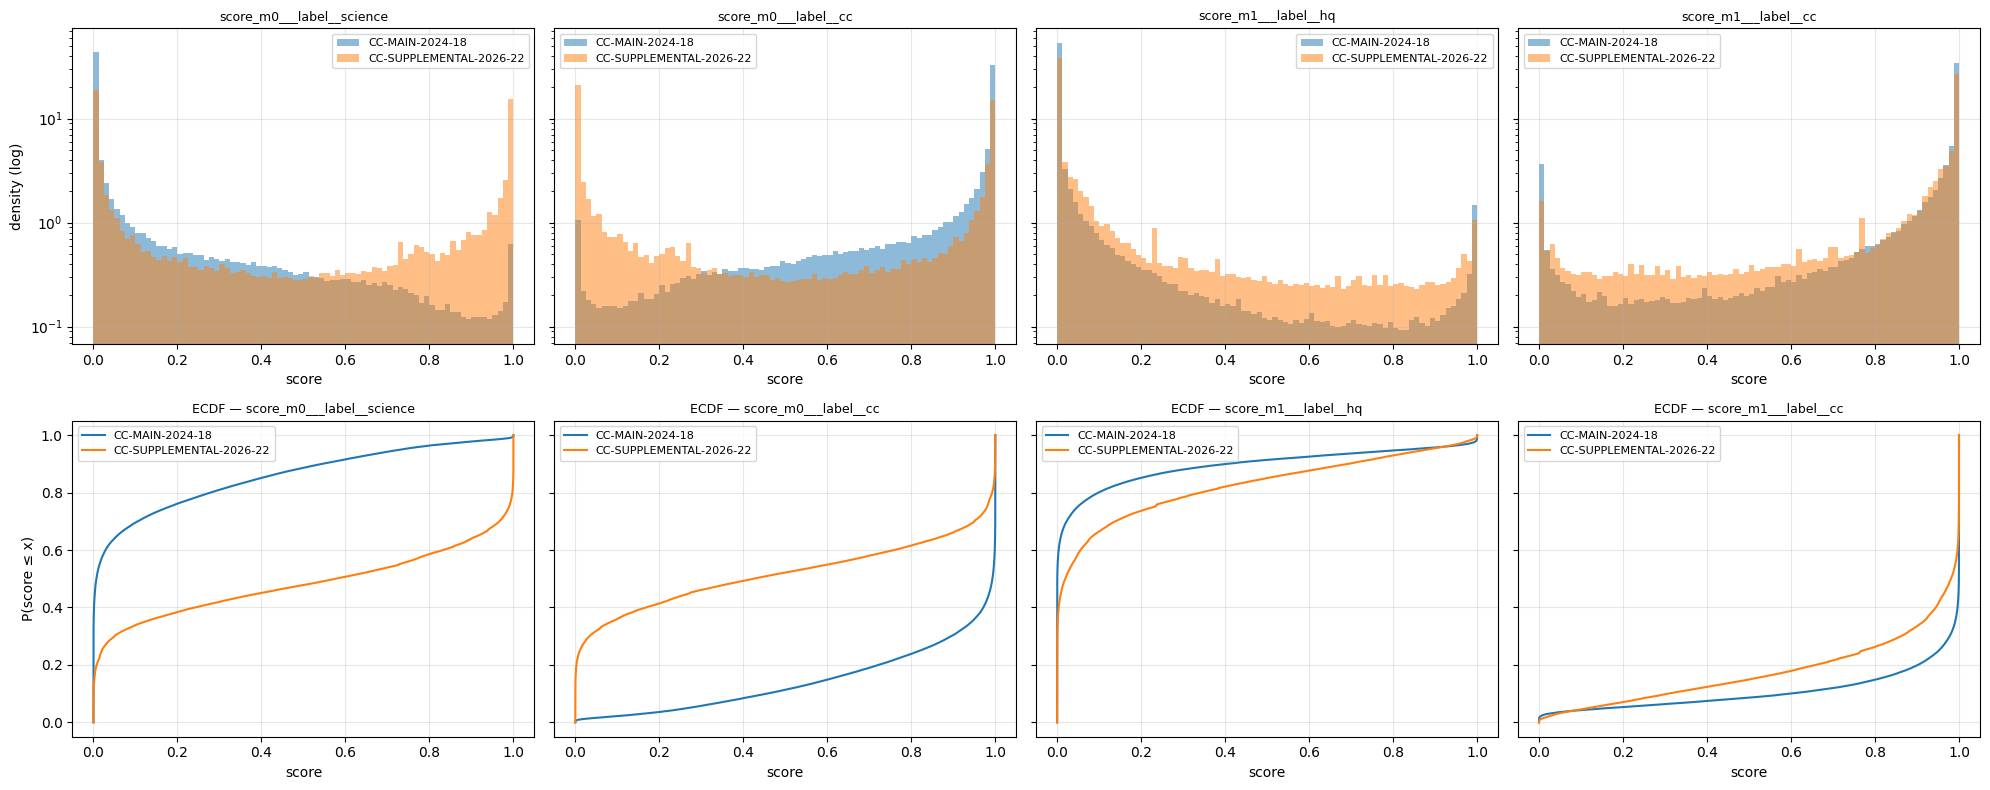

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharey="row")
bins = np.linspace(0.0, 1.0, 81)

for col_idx, col in enumerate(SCORE_COLS):
    ax = axes[0, col_idx]
    ax.hist(baseline[col], bins=bins, alpha=0.5, label=BASELINE_NAME, color="C0", density=True)
    ax.hist(focus[col], bins=bins, alpha=0.5, label=FOCUS_NAME, color="C1", density=True)
    ax.set_yscale("log")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("score")
    if col_idx == 0:
        ax.set_ylabel("density (log)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1, col_idx]
    for series, label, color in [
        (baseline[col], BASELINE_NAME, "C0"),
        (focus[col], FOCUS_NAME, "C1"),
    ]:
        x = np.sort(series.to_numpy())
        y = np.arange(1, len(x) + 1) / len(x)
        ax.plot(x, y, label=label, color=color)
    ax.set_title(f"ECDF — {col}", fontsize=9)
    ax.set_xlabel("score")
    if col_idx == 0:
        ax.set_ylabel("P(score \u2264 x)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Binary labels from the score pairs

We collapse each classifier's two scores into a single boolean by picking the larger one:

- `is_science = score_m0___label__science > score_m0___label__cc`
- `is_hq      = score_m1___label__hq      > score_m1___label__cc`

And then the joint label that interests us most:

- `is_sci_and_hq = is_science AND is_hq`

In [5]:
def add_binary_labels(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["is_science"] = out[SCI_SCIENCE] > out[SCI_CC]
    out["is_hq"] = out[HQ_HQ] > out[HQ_CC]
    out["is_sci_and_hq"] = out["is_science"] & out["is_hq"]
    return out


baseline_lbl = add_binary_labels(baseline)
focus_lbl = add_binary_labels(focus)


def prevalence(df: pd.DataFrame) -> dict:
    n = len(df)
    return {
        "n": n,
        "is_science_count": int(df["is_science"].sum()),
        "is_science_share": df["is_science"].mean(),
        "is_hq_count": int(df["is_hq"].sum()),
        "is_hq_share": df["is_hq"].mean(),
        "is_sci_and_hq_count": int(df["is_sci_and_hq"].sum()),
        "is_sci_and_hq_share": df["is_sci_and_hq"].mean(),
    }


prev = pd.DataFrame({BASELINE_NAME: prevalence(baseline_lbl), FOCUS_NAME: prevalence(focus_lbl)})
prev["lift (focus / baseline)"] = prev[FOCUS_NAME] / prev[BASELINE_NAME].replace({0: np.nan})
prev.round(6)

,CC-MAIN-2024-18,CC-SUPPLEMENTAL-2026-22,lift (focus / baseline)
n,1000000.000000,999774.000000,0.999774
is_science_count,113543.000000,521658.000000,4.594365
is_science_share,0.113543,0.521776,4.595404
is_hq_count,85984.000000,149159.000000,1.734730
is_hq_share,0.085984,0.149193,1.735122
is_sci_and_hq_count,21508.000000,118576.000000,5.513111
is_sci_and_hq_share,0.021508,0.118603,5.514358


## 5. How do the two classifiers agree?

A 2×2 contingency table between `is_science` and `is_hq`, separately for each crawl. The bottom-right cell (`science=True, hq=True`) is the joint label we care most about.

In [6]:
def crosstab(df: pd.DataFrame) -> pd.DataFrame:
    return pd.crosstab(df["is_science"], df["is_hq"], margins=True, margins_name="total")


print(f"\n=== {BASELINE_NAME} ===")
print(crosstab(baseline_lbl))
print(f"\n=== {FOCUS_NAME} ===")
print(crosstab(focus_lbl))


=== CC-MAIN-2024-18 ===
is_hq        False   True    total
is_science                        
False       821981  64476   886457
True         92035  21508   113543
total       914016  85984  1000000

=== CC-SUPPLEMENTAL-2026-22 ===
is_hq        False    True   total
is_science                        
False       447533   30583  478116
True        403082  118576  521658
total       850615  149159  999774


## 6. Joint label — baseline vs focus

Absolute counts on the left, share-of-crawl on the right. The third group of bars (`is_science AND is_hq`) is the headline.

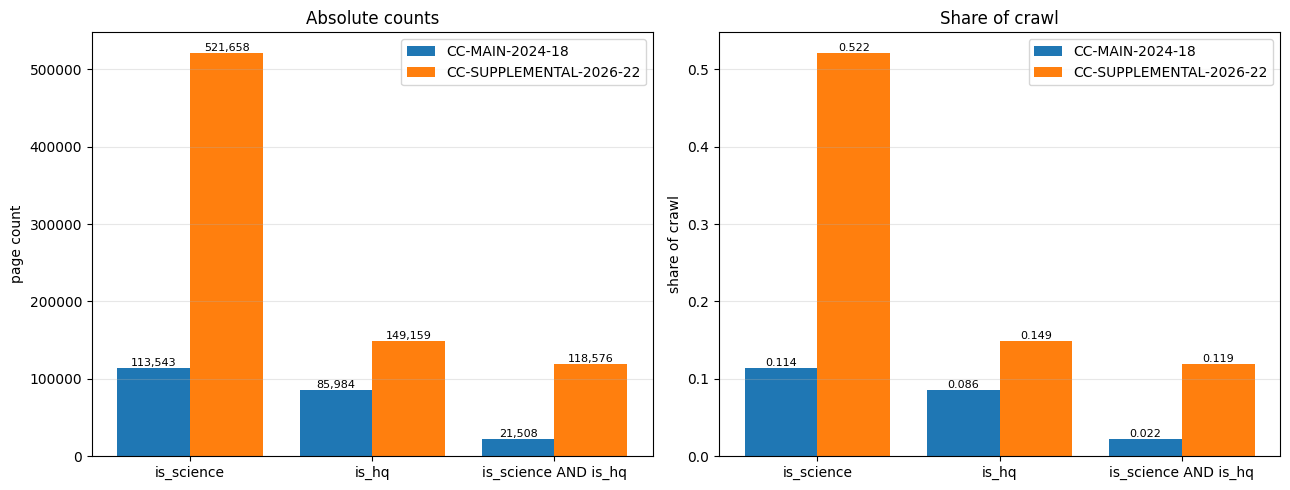

In [7]:
labels = ["is_science", "is_hq", "is_science AND is_hq"]
baseline_counts = [
    int(baseline_lbl["is_science"].sum()),
    int(baseline_lbl["is_hq"].sum()),
    int(baseline_lbl["is_sci_and_hq"].sum()),
]
focus_counts = [
    int(focus_lbl["is_science"].sum()),
    int(focus_lbl["is_hq"].sum()),
    int(focus_lbl["is_sci_and_hq"].sum()),
]
baseline_shares = [c / len(baseline_lbl) for c in baseline_counts]
focus_shares = [c / len(focus_lbl) for c in focus_counts]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(labels))
w = 0.4

axes[0].bar(x - w / 2, baseline_counts, w, label=BASELINE_NAME, color="C0")
axes[0].bar(x + w / 2, focus_counts, w, label=FOCUS_NAME, color="C1")
for i, (b, f) in enumerate(zip(baseline_counts, focus_counts, strict=True)):
    axes[0].text(i - w / 2, b, f"{b:,}", ha="center", va="bottom", fontsize=8)
    axes[0].text(i + w / 2, f, f"{f:,}", ha="center", va="bottom", fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("page count")
axes[0].set_title("Absolute counts")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(x - w / 2, baseline_shares, w, label=BASELINE_NAME, color="C0")
axes[1].bar(x + w / 2, focus_shares, w, label=FOCUS_NAME, color="C1")
for i, (b, f) in enumerate(zip(baseline_shares, focus_shares, strict=True)):
    axes[1].text(i - w / 2, b, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
    axes[1].text(i + w / 2, f, f"{f:.3f}", ha="center", va="bottom", fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("share of crawl")
axes[1].set_title("Share of crawl")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Significance and effect size on the binary labels

For each binary label we run a 2×2 chi-square test on the (focus vs baseline) × (label vs not-label) contingency table. With ~1M rows per crawl, p-values will be effectively 0 for any non-trivial difference, so the **rate ratio** (focus rate / baseline rate) is the substantive answer.

We complement the chi-square with a **two-sample Kolmogorov–Smirnov test** on the underlying continuous scores (`score___label__science` and `score___label__hq`) so the comparison is grounded in distributional differences, not just thresholded labels.

In [8]:
rows = []
for label in ("is_science", "is_hq", "is_sci_and_hq"):
    f_pos = int(focus_lbl[label].sum())
    f_neg = len(focus_lbl) - f_pos
    b_pos = int(baseline_lbl[label].sum())
    b_neg = len(baseline_lbl) - b_pos
    table = np.array([[f_pos, f_neg], [b_pos, b_neg]])
    chi2, p, _dof, _ = stats.chi2_contingency(table)
    p_focus = f_pos / len(focus_lbl)
    p_base = b_pos / len(baseline_lbl) if len(baseline_lbl) else 0.0
    ratio = p_focus / p_base if p_base else float("inf")
    rows.append(
        {
            "label": label,
            f"{BASELINE_NAME} rate": p_base,
            f"{FOCUS_NAME} rate": p_focus,
            "rate ratio (focus / baseline)": ratio,
            "chi2": chi2,
            "p": p,
        }
    )
chi_df = pd.DataFrame(rows).set_index("label")

ks_rows = []
for col, friendly in [(SCI_SCIENCE, "science prob."), (HQ_HQ, "HQ prob.")]:
    ks = stats.ks_2samp(baseline[col], focus[col], method="auto")
    ks_rows.append(
        {
            "column": col,
            "name": friendly,
            "KS statistic": ks.statistic,
            "KS p": ks.pvalue,
        }
    )
ks_df = pd.DataFrame(ks_rows).set_index("column")

print("Chi-square on binary labels:")
print(chi_df.round(6).to_string())
print("\nKolmogorov\u2013Smirnov on continuous scores:")
print(ks_df.round(6).to_string())

Chi-square on binary labels:
               CC-MAIN-2024-18 rate  CC-SUPPLEMENTAL-2026-22 rate  rate ratio (focus / baseline)           chi2    p
label                                                                                                               
is_science                 0.113543                      0.521776                       4.595404  384404.736904  0.0
is_hq                      0.085984                      0.149193                       1.735122   19250.278261  0.0
is_sci_and_hq              0.021508                      0.118603                       5.514358   72349.694228  0.0

Kolmogorov–Smirnov on continuous scores:
                                    name  KS statistic  KS p
column                                                      
score_m0___label__science  science prob.      0.409693   0.0
score_m1___label__hq            HQ prob.      0.213082   0.0


## 8. Verdict

One-paragraph summary computed from the cells above.

In [9]:
sci_lift = focus_lbl["is_science"].mean() / max(baseline_lbl["is_science"].mean(), 1e-12)
hq_lift = focus_lbl["is_hq"].mean() / max(baseline_lbl["is_hq"].mean(), 1e-12)
joint_lift = focus_lbl["is_sci_and_hq"].mean() / max(baseline_lbl["is_sci_and_hq"].mean(), 1e-12)

b_joint = int(baseline_lbl["is_sci_and_hq"].sum())
f_joint = int(focus_lbl["is_sci_and_hq"].sum())

print(f"Comparison: {FOCUS_NAME} vs {BASELINE_NAME}")
print(f"  is_science      focus={focus_lbl['is_science'].mean():.4f}  baseline={baseline_lbl['is_science'].mean():.4f}  lift={sci_lift:.2f}x")
print(f"  is_hq           focus={focus_lbl['is_hq'].mean():.4f}  baseline={baseline_lbl['is_hq'].mean():.4f}  lift={hq_lift:.2f}x")
print(f"  is_sci_and_hq   focus={focus_lbl['is_sci_and_hq'].mean():.4f}  baseline={baseline_lbl['is_sci_and_hq'].mean():.4f}  lift={joint_lift:.2f}x")
print()
print("Joint pages (science AND high quality):")
print(f"  {BASELINE_NAME}: {b_joint:,} of {len(baseline_lbl):,}")
print(f"  {FOCUS_NAME}:    {f_joint:,} of {len(focus_lbl):,}")
print(f"  absolute delta: {f_joint - b_joint:+,d}  (focus has {joint_lift:.2f}x the rate of the baseline)")

Comparison: CC-SUPPLEMENTAL-2026-22 vs CC-MAIN-2024-18
  is_science      focus=0.5218  baseline=0.1135  lift=4.60x
  is_hq           focus=0.1492  baseline=0.0860  lift=1.74x
  is_sci_and_hq   focus=0.1186  baseline=0.0215  lift=5.51x

Joint pages (science AND high quality):
  CC-MAIN-2024-18: 21,508 of 1,000,000
  CC-SUPPLEMENTAL-2026-22:    118,576 of 999,774
  absolute delta: +97,068  (focus has 5.51x the rate of the baseline)
